| ID  | Pergunta de Pesquisa                                                                                                                                                | Alternativas de Resposta (como será respondida)                                                                      | Dificuldade (1–10) |
| --- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- | ------------------ |
| QP1 | Qual ferramenta de map matching apresenta maior acurácia no paradigma online sob diferentes taxas de amostragem das trajetórias?                                    | Comparação de métricas de acurácia agregadas por ferramenta e taxa de amostragem, com análise estatística descritiva | **4**              |
| QP2 | Qual ferramenta apresenta maior eficiência temporal no processamento online de trajetórias, considerando métricas de latência e variabilidade temporal (p95 e p99)? | Análise de latência média, p95 e p99 por ferramenta, com comparação direta entre distribuições                       | **3**              |
| QP3 | Qual ferramenta apresenta maior eficiência computacional, considerando a relação entre acurácia obtida e custo computacional (uso de CPU e memória)?                | Construção de métricas compostas ou análise pareada entre acurácia e consumo médio de CPU e memória                  | **6**              |
| QP4 | Qual ferramenta apresenta maior capacidade de processamento contínuo ao lidar com trajetórias longas e diferentes taxas de amostragem no paradigma online?          | Avaliação de throughput (pontos/s, km/s ou trajetórias/s) em cenários com trajetórias longas                         | **5**              |
| QP5 | Qual é o impacto do uso de processamento em lotes na acurácia e no desempenho computacional das ferramentas avaliadas?                                              | Comparação direta entre cenários com e sem batch, analisando diferenças relativas nas métricas                       | **4**              |


## Respostas

**QP1.** Melhor acurácia no online por taxa de amostragem (média de `accuracy` por ferramenta):

- sr=1.0: **barefoot** (0.9312)
- sr=5.0: **barefoot** (0.9777)
- sr=10.0: **barefoot** (0.9710)
- sr=20.0: **barefoot** (0.9548)

**QP2.** Eficiência temporal no online (média de latência por ferramenta):

- **barefoot**: p95=306.05 ms, p99=308.05 ms, média=283.35 ms
- graphium: p95=5456.12 ms, p99=5700.10 ms, média=4671.13 ms

Resposta: **barefoot** apresenta a menor latência e variabilidade (p95/p99).

**QP3.** Eficiência computacional (online), usando métrica composta `accuracy / (cpu_avg * mem_avg_mb)`:

- **barefoot**: 0.03126
- graphium: 0.00050

Resposta: **barefoot** tem a melhor relação acurácia/custo computacional.

**QP4.** Throughput (online) por taxa de amostragem (média de `e2e_throughput_pps`):

- sr=1.0: **graphium** (32.60 pts/s)
- sr=5.0: **graphium** (13.70 pts/s)
- sr=10.0: **graphium** (29.61 pts/s)
- sr=20.0: **barefoot** (1.64 pts/s)

Resposta: **graphium** domina em 1.0, 5.0 e 10.0; **barefoot** aparece como melhor em 20.0.

**QP5.** Impacto de batch vs non-batch (médias globais):

- batch: accuracy=0.8132, cpu_avg=0.534, mem_avg=599.33 MB, p95=4041.30 ms
- non-batch: accuracy=0.9587, cpu_avg=0.253, mem_avg=189.89 MB, p95=306.05 ms

Resposta: o uso de batch **reduz acurácia** e **piora desempenho** (maior CPU/memória e p95) nos dados agregados.


In [40]:
from pathlib import Path
import re

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import plotly.express as px


In [41]:
RESULTS_PATH = Path.cwd() / "results"

e2e_path = RESULTS_PATH / "aggregated_e2e_metrics.csv"
match_path = RESULTS_PATH / "aggregated_match_metrics.csv"
prometheus_path = RESULTS_PATH / "aggregated_prometheus_metrics.csv"
final_path = RESULTS_PATH / "final_runs_table.csv"

def read_csv(path: Path) -> pd.DataFrame:
    return duckdb.read_csv(path).to_df()

def add_throughput_km_per_s(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["e2e_throughput_km_per_s"] = df["total_gt_length"] / df["e2e_execution_time_s"]
    return df

def extract_sample_rate(dataset_id: str) -> float | None:
    m = re.search(r"sr_(\d+(\.\d+)?)", str(dataset_id))
    return float(m.group(1)) if m else None

def add_sample_rate(df: pd.DataFrame, column: str) -> pd.DataFrame:
    out = df.copy()
    out["sample_rate"] = out[column].apply(extract_sample_rate)
    return out

def plot_line_by_group(
    df: pd.DataFrame,
    x: str,
    y: str,
    group: str,
    *,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize: tuple[int, int] | None = None,
    order: list[str] | None = None,
    colors: dict[str, str] | None = None,
) -> None:
    if figsize:
        plt.figure(figsize=figsize)
    else:
        plt.figure()

    groups = order if order is not None else df[group].dropna().unique()
    for name in groups:
        g = df[df[group] == name]
        if g.empty:
            continue
        plt.plot(
            g[x],
            g[y],
            marker="o",
            label=name,
            color=colors.get(name) if colors else None,
        )

    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [42]:
e2e_df = read_csv(e2e_path)
e2e_df


,run_id,matcher_name,mode,step_index,timestamp,step_latency_ms,inter_arrival_ms,points_per_step,cum_points,memory_mb,cpu_time_ms
0,16523baf49f64af2920f43fbc652ea15,graphium,online,0,1.768186e+09,1192.833003,NaN,30,30,314.90625,10.0
1,16523baf49f64af2920f43fbc652ea15,graphium,online,1,1.768186e+09,182.609144,182.775974,5,35,314.90625,0.0
2,16523baf49f64af2920f43fbc652ea15,graphium,online,2,1.768186e+09,178.779128,178.938150,5,40,314.90625,0.0
3,16523baf49f64af2920f43fbc652ea15,graphium,online,3,1.768186e+09,179.915613,180.033445,5,45,314.90625,0.0
4,16523baf49f64af2920f43fbc652ea15,graphium,online,4,1.768186e+09,218.816028,218.941450,5,50,314.90625,0.0
...,...,...,...,...,...,...,...,...,...,...,...
14184,15a74036e9fe4f108949b14626cde04e,osrm,offline,2,1.768199e+09,3344.208166,3344.361305,5,15,338.75000,10.0
14185,15a74036e9fe4f108949b14626cde04e,osrm,offline,3,1.768199e+09,0.185594,0.252724,0,15,338.75000,0.0
14186,672439444d6944ccace434e680f85e34,osrm,offline,0,1.768199e+09,6018.144771,NaN,10,10,338.90625,0.0
14187,672439444d6944ccace434e680f85e34,osrm,offline,1,1.768199e+09,3344.282321,3344.424009,5,15,338.90625,10.0


In [43]:
match_df = read_csv(match_path)
match_df


,run_id,precision,recall,f1_score,error_rate,accuracy,newson_krumm_error,matched_count,added_count,missing_count,...,total_added_length,total_missing_length,vehicle_id,experiment_id,dataset_id,matcher_name,mode,adapter,batch_size,gps_accuracy
0,9452b53d65ad46e7bca784e891330c42,0.972407,0.913960,0.942278,0.057722,0.890856,0.111975,10,1,2,...,17.812997,59.095339,1139,16523baf49f64af2920f43fbc652ea15,ohare_filtered_vid_1139_sr_1.0,graphium,online,native,5.0,NaN
1,318c151658d24539b965db7f45735ab1,0.972407,0.913960,0.942278,0.057722,0.890856,0.111975,10,1,2,...,17.812997,59.095339,1139,324ea397c7a54ad18e1339fa50aed98c,ohare_filtered_vid_1139_sr_1.0,graphium,online,native,10.0,NaN
2,071f4bfd3a6e4ec488709d8baa97955b,0.972407,0.913960,0.942278,0.057722,0.890856,0.111975,10,1,2,...,17.812997,59.095339,1139,565006ebd2e74bf4945c81eb16ab6a1b,ohare_filtered_vid_1139_sr_1.0,graphium,online,native,30.0,NaN
3,38862d8619234220aa348dcdeb4000e0,0.956736,1.000000,0.977890,0.022110,0.956736,0.045220,12,2,0,...,31.059085,0.000000,1139,44a75e620a77492daa67aaf769ae6d9c,ohare_filtered_vid_1139_sr_1.0,barefoot,online,native,NaN,NaN
4,0ce2d2b28c90408f8c0bba7c7d41fac8,0.609645,0.901038,0.727238,0.272762,0.571386,0.675896,10,7,2,...,396.259501,67.970605,1139,a06171e307184813a754e7f5924c407e,ohare_filtered_vid_1139_sr_1.0,graphhopper,offline,batches,5.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,b287c480aac74ff880eb803fe05ca937,0.961322,0.869725,0.913232,0.086768,0.840320,0.165268,21,2,8,...,85.867008,319.680124,1423,18ce1cb4394346febcc7ae922852a78c,ohare_filtered_vid_1423_sr_20.0,graphhopper,offline,batches,10.0,50.0
786,1231a2a5a61c4380804ba1984ec75373,0.963249,0.917145,0.939631,0.060369,0.886137,0.117848,24,2,5,...,85.867008,203.317191,1423,e9ed28d1b51844e09b87b7243679b2f7,ohare_filtered_vid_1423_sr_20.0,graphhopper,offline,batches,30.0,50.0
787,90a68f9b77c4457daf6e1f81e35ded83,0.976326,0.801149,0.880105,0.119895,0.785882,0.218277,18,1,11,...,47.669382,487.956680,1423,15a74036e9fe4f108949b14626cde04e,ohare_filtered_vid_1423_sr_20.0,osrm,offline,batches,5.0,NaN
788,5f44a93a1ec54afe903b447df21c8e38,0.976326,0.801149,0.880105,0.119895,0.785882,0.218277,18,1,11,...,47.669382,487.956680,1423,672439444d6944ccace434e680f85e34,ohare_filtered_vid_1423_sr_20.0,osrm,offline,batches,10.0,NaN


In [44]:
prometheus_df = read_csv(prometheus_path)
prometheus_df


,duration_s,cpu_avg,cpu_max,cpu_total_core_s,mem_avg_mb,mem_peak_mb,rx_avg_bps,tx_avg_bps,rx_peak_bps,tx_peak_bps,rx_total_bytes,tx_total_bytes,matcher_name,mode,dataset_id,experiment_id,vehicle_id,adapter,batch_size,gps_accuracy
0,15.0,1.643418,2.476856,24.900649,1433.749512,1492.902344,1225.355153,1726.482962,2708.800000,4123.350000,19605.682452,2.762373e+04,graphium,online,ohare_filtered_vid_1139_sr_1.0,16523baf49f64af2920f43fbc652ea15,1139,native,5.0,NaN
1,14.0,1.745557,2.935444,24.904509,1439.782813,1491.480469,709.491711,657.340019,1297.477943,1389.500000,10642.375661,9.860100e+03,graphium,online,ohare_filtered_vid_1139_sr_1.0,324ea397c7a54ad18e1339fa50aed98c,1139,native,10.0,NaN
2,14.0,1.653615,2.772860,23.480448,1446.583854,1493.328125,563.937348,452.448820,1118.050000,1002.225000,8459.060219,6.786732e+03,graphium,online,ohare_filtered_vid_1139_sr_1.0,565006ebd2e74bf4945c81eb16ab6a1b,1139,native,30.0,NaN
3,7.0,0.378917,0.426825,2.665077,195.839844,221.234375,16946.145207,152380.020378,19332.196681,209615.798802,135569.161659,1.219040e+06,barefoot,online,ohare_filtered_vid_1139_sr_1.0,44a75e620a77492daa67aaf769ae6d9c,1139,native,NaN,NaN
4,12.0,0.385815,0.726321,4.518585,295.956771,349.316406,1805.716314,987.939743,3221.175000,1865.600000,23474.312085,1.284322e+04,graphhopper,offline,ohare_filtered_vid_1139_sr_1.0,a06171e307184813a754e7f5924c407e,1139,batches,5.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,18.0,0.274625,0.615558,4.643612,334.392578,357.375000,287.340894,94.898796,414.849091,228.433333,5459.476982,1.803077e+03,graphhopper,offline,ohare_filtered_vid_1423_sr_20.0,18ce1cb4394346febcc7ae922852a78c,1423,batches,10.0,50.0
786,18.0,0.239055,0.732729,4.100579,296.030469,313.644531,138.884052,5.228701,299.675724,14.303416,2638.796985,9.934533e+01,graphhopper,offline,ohare_filtered_vid_1423_sr_20.0,e9ed28d1b51844e09b87b7243679b2f7,1423,batches,30.0,50.0
787,13.0,0.000343,0.000573,0.004408,3.881836,5.074219,341.472671,573.074571,560.527258,976.078746,4780.617387,8.023044e+03,osrm,offline,ohare_filtered_vid_1423_sr_20.0,15a74036e9fe4f108949b14626cde04e,1423,batches,5.0,NaN
788,12.0,0.000632,0.001066,0.007152,3.032031,3.917969,296.743839,518.034971,459.656377,884.038180,3857.669907,6.734455e+03,osrm,offline,ohare_filtered_vid_1423_sr_20.0,672439444d6944ccace434e680f85e34,1423,batches,10.0,NaN


In [45]:
final_runs_df = add_throughput_km_per_s(read_csv(final_path))
final_runs_df


,duration_s,cpu_avg,cpu_max,cpu_total_core_s,mem_avg_mb,mem_peak_mb,rx_avg_bps,tx_avg_bps,rx_peak_bps,tx_peak_bps,...,e2e_avg_inter_arrival_ms,e2e_p50_inter_arrival_ms,e2e_p75_inter_arrival_ms,e2e_p95_inter_arrival_ms,e2e_p99_inter_arrival_ms,e2e_max_inter_arrival_ms,e2e_avg_points_per_step,e2e_client_mem_peak_mb,e2e_client_cpu_time_ms,e2e_throughput_km_per_s
0,15.0,1.643418,2.476856,24.900649,1433.749512,1492.902344,1225.355153,1726.482962,2708.800000,4123.350000,...,175.478318,178.727388,180.033445,190.009069,213.154974,218.941450,6.222222,314.906250,50.0,230.240177
1,14.0,1.745557,2.935444,24.904509,1439.782813,1491.480469,709.491711,657.340019,1297.477943,1389.500000,...,326.990181,351.133585,352.983952,386.070156,402.083569,406.086922,11.200000,328.164062,40.0,233.386811
2,14.0,1.653615,2.772860,23.480448,1446.583854,1493.328125,563.937348,452.448820,1118.050000,1002.225000,...,955.418507,1043.594599,1050.235868,1055.548882,1056.611485,1056.877136,28.000000,328.164062,30.0,239.628568
3,7.0,0.378917,0.426825,2.665077,195.839844,221.234375,16946.145207,152380.020378,19332.196681,209615.798802,...,34.580809,34.567356,35.793304,37.380576,38.146210,39.592743,1.000000,328.476562,200.0,178.935032
4,12.0,0.385815,0.726321,4.518585,295.956771,349.316406,1805.716314,987.939743,3221.175000,1865.600000,...,177.236568,181.450248,182.985961,188.821447,193.970988,195.305347,4.869565,328.476562,90.0,176.147895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,18.0,0.274625,0.615558,4.643612,334.392578,357.375000,287.340894,94.898796,414.849091,228.433333,...,3362.779856,3362.779856,3362.779856,3362.779856,3362.779856,3362.779856,7.500000,338.750000,10.0,729.717334
786,18.0,0.239055,0.732729,4.100579,296.030469,313.644531,138.884052,5.228701,299.675724,14.303416,...,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,338.750000,10.0,inf
787,13.0,0.000343,0.000573,0.004408,3.881836,5.074219,341.472671,573.074571,560.527258,976.078746,...,2229.577700,3344.119072,3344.240189,3344.337082,3344.356461,3344.361305,3.750000,338.750000,10.0,366.867494
788,12.0,0.000632,0.001066,0.007152,3.032031,3.917969,296.743839,518.034971,459.656377,884.038180,...,3344.424009,3344.424009,3344.424009,3344.424009,3344.424009,3344.424009,7.500000,338.906250,10.0,733.722382


In [46]:
final_runs_df["matcher_name"].value_counts()

matcher_name
graphhopper    240
graphium       239
osrm           231
barefoot        80
Name: count, dtype: int64

In [47]:
graphium_runs = final_runs_df
graphium_runs_zero_time = graphium_runs[graphium_runs["e2e_execution_time_s"] == 0]
graphium_runs_zero_time[["matcher_name", "batch_size_prom", "dataset_id_prom"]].groupby(
    ["matcher_name", "batch_size_prom"]).count()


dataset_id_prom
matcher_name batch_size_prom                 
graphhopper  10.0                           5
             30.0                          35
graphium     5.0                           36
             10.0                          36
             30.0                          36
osrm         10.0                           5
             30.0                          35

**QP1.** Melhor acurácia no online por taxa de amostragem (média de `accuracy` por ferramenta):

In [48]:
final_runs_df_agg = duckdb.query(
    """
    SELECT
        matcher_name, mode, adapter_prom as adapter,
        AVG(e2e_throughput_pps) AS e2e_throughput_pps_avg,
        AVG(e2e_avg_step_latency_ms) AS e2e_avg_step_latency_ms_avg,
        AVG(e2e_p95_step_latency_ms) AS e2e_p95_step_latency_ms_avg,
        AVG(e2e_p99_step_latency_ms) AS e2e_p99_step_latency_ms_avg,
        SUM(e2e_execution_time_s) AS e2e_execution_time_s_sum,
        AVG(cpu_avg) AS sr_cpu_avg,
        AVG(mem_avg_mb) AS sr_mem_mb_avg,
        AVG(accuracy) AS match_accuracy_avg,
        AVG(precision) AS match_precision_avg,
        AVG(recall) AS match_recall_avg,
        AVG(f1_score) AS match_f1_score_avg,
        AVG(error_rate) AS match_error_rate_avg,
        AVG(newson_krumm_error) AS match_newson_krumm_error_avg,
        SUM(total_gt_length) / AVG(e2e_execution_time_s) AS e2e_throughput_km_per_s

    FROM final_runs_df
    GROUP BY matcher_name, mode, adapter
    ORDER BY matcher_name, mode
    """
).to_df()
final_runs_df_agg

,matcher_name,mode,adapter,e2e_throughput_pps_avg,e2e_avg_step_latency_ms_avg,e2e_p95_step_latency_ms_avg,e2e_p99_step_latency_ms_avg,e2e_execution_time_s_sum,sr_cpu_avg,sr_mem_mb_avg,match_accuracy_avg,match_precision_avg,match_recall_avg,match_f1_score_avg,match_error_rate_avg,match_newson_krumm_error_avg,e2e_throughput_km_per_s
0,barefoot,online,native,9.946762,283.347170,306.046626,308.051400,711.058097,0.253312,189.891428,0.958685,0.981619,0.975902,0.978118,0.021882,0.043686,14945.088059
1,graphhopper,offline,batches,552.495259,2854.044491,3290.542206,3322.247460,1399.932667,0.286774,326.453025,0.721862,0.826867,0.824468,0.814973,0.185027,0.380320,68318.595012
2,graphium,online,native,25.126663,4671.132345,5456.121102,5700.102711,807.554191,1.296456,1447.483308,0.904941,0.975432,0.923417,0.946909,0.053091,0.102184,117411.007869
3,osrm,offline,batches,614.485738,2910.486628,3357.487196,3383.682416,1288.595020,0.001121,5.297504,0.813050,0.970129,0.838167,0.889189,0.110811,0.193359,68526.529831


In [49]:
final_runs_df_agg = (
    final_runs_df.groupby(["matcher_name", "mode"]).agg(
        {
            "e2e_throughput_pps": "mean",
            "e2e_avg_step_latency_ms": "mean",
            "e2e_p95_step_latency_ms": "mean",
            "e2e_p99_step_latency_ms": "mean",
            "cpu_avg": "mean",
            "mem_avg_mb": "mean",
            "accuracy": "mean",
        }
    ).reset_index()
)
final_runs_df_agg

,matcher_name,mode,e2e_throughput_pps,e2e_avg_step_latency_ms,e2e_p95_step_latency_ms,e2e_p99_step_latency_ms,cpu_avg,mem_avg_mb,accuracy
0,barefoot,online,9.946762,283.347170,306.046626,308.051400,0.253312,189.891428,0.958685
1,graphhopper,offline,552.495259,2854.044491,3290.542206,3322.247460,0.286774,326.453025,0.721862
2,graphium,online,25.126663,4671.132345,5456.121102,5700.102711,1.296456,1447.483308,0.904941
3,osrm,offline,614.485738,2910.486628,3357.487196,3383.682416,0.001121,5.297504,0.813050


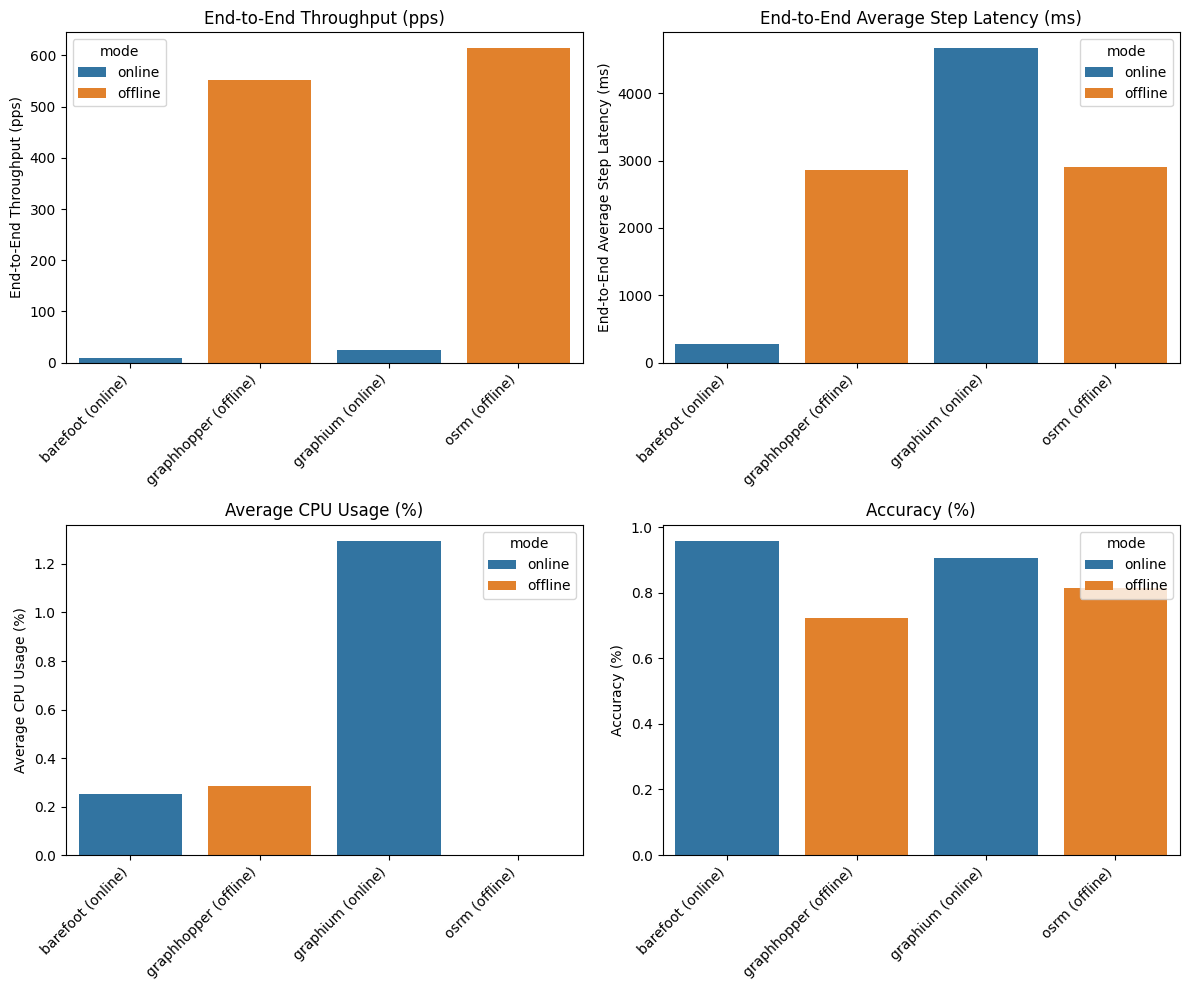

In [50]:
# plot final_runs_df_agg using seaborn
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()
metrics = [
    "e2e_throughput_pps",
    "e2e_avg_step_latency_ms",
    "cpu_avg",
    "accuracy",
]
titles = [
    "End-to-End Throughput (pps)",
    "End-to-End Average Step Latency (ms)",
    "Average CPU Usage (%)",
    "Accuracy (%)",
]

for i, metric in enumerate(metrics):
    final_runs_df_agg['label'] = final_runs_df_agg['matcher_name'] + ' (' + final_runs_df_agg['mode'] + ')'
    sns.barplot(data=final_runs_df_agg, x='label', y=metric, hue='mode', ax=axs[i])
    axs[i].set_title(titles[i])
    axs[i].set_ylabel(titles[i])
    axs[i].set_xlabel('')
    axs[i].tick_params(axis='x', rotation=45)
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


   matcher_name  sample_rate   f1_mean  error_rate_mean  nk_error_mean  runs
0      barefoot          1.0  0.962462         0.037538       0.077555    20
1      barefoot          5.0  0.988539         0.011461       0.022625    20
2      barefoot         10.0  0.985045         0.014955       0.029302    20
3      barefoot         20.0  0.976424         0.023576       0.045261    20
4   graphhopper          1.0  0.786160         0.213840       0.488753    60
5   graphhopper          5.0  0.864142         0.135858       0.283907    60
6   graphhopper         10.0  0.838023         0.161977       0.314321    60
7   graphhopper         20.0  0.771570         0.228430       0.434299    60
8      graphium          1.0  0.930768         0.069232       0.138932    59
9      graphium          5.0  0.937322         0.062678       0.121365    60
10     graphium         10.0  0.962715         0.037285       0.069206    60
11     graphium         20.0  0.956563         0.043437       0.079846    60

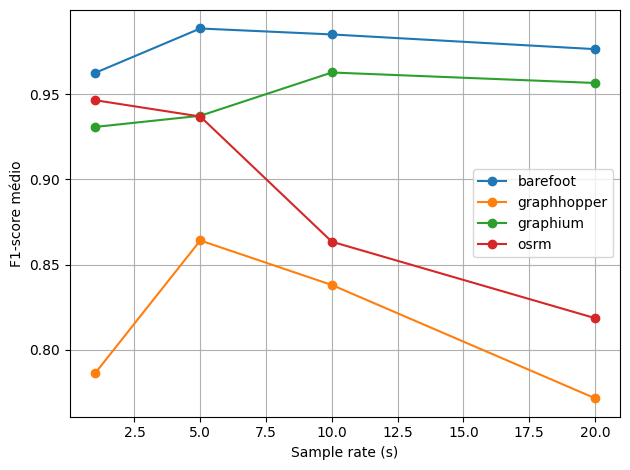

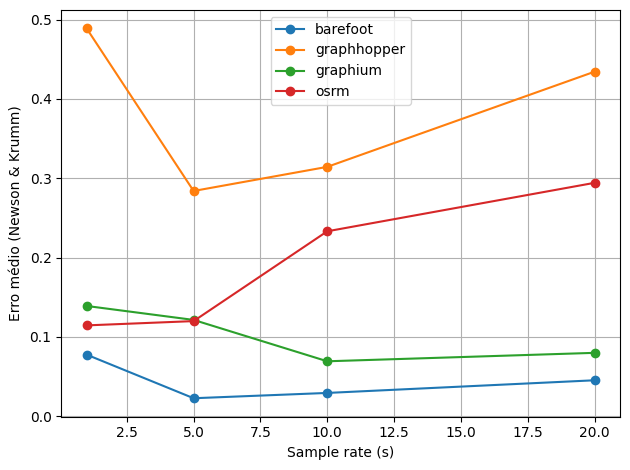

In [51]:
# --------------------------------------------------
# Load data
# --------------------------------------------------
df = read_csv(final_path)

# --------------------------------------------------
# Extract sample rate from dataset_id_prom
# Example: ohare_filtered_vid_1139_sr_5.0 -> 5.0
# --------------------------------------------------
df = add_sample_rate(df, "dataset_id_prom")

# Sanity check
df = df.dropna(subset=["sample_rate"])

# --------------------------------------------------
# Aggregate metrics for QP1
# --------------------------------------------------
qp1_agg = (
    df.groupby(["matcher_name", "sample_rate"], as_index=False)
    .agg(
        f1_mean=("f1_score", "mean"),
        error_rate_mean=("error_rate", "mean"),
        nk_error_mean=("newson_krumm_error", "mean"),
        runs=("f1_score", "count"),
    )
    .sort_values(["matcher_name", "sample_rate"])
)

print(qp1_agg)

# --------------------------------------------------
# Plot 1: F1-score vs sample rate
# --------------------------------------------------
plot_line_by_group(
    qp1_agg,
    x="sample_rate",
    y="f1_mean",
    group="matcher_name",
    xlabel="Sample rate (s)",
    ylabel="F1-score médio",
)

# --------------------------------------------------
# Plot 2: Newson–Krumm error vs sample rate
# --------------------------------------------------
plot_line_by_group(
    qp1_agg,
    x="sample_rate",
    y="nk_error_mean",
    group="matcher_name",
    xlabel="Sample rate (s)",
    ylabel="Erro médio (Newson & Krumm)",
)


   matcher_name  sample_rate  latency_mean_ms  runs
0      barefoot          1.0        34.537087    20
1      barefoot          5.0       164.426410    20
2      barefoot         10.0       320.627659    20
3      barefoot         20.0       613.797522    20
4   graphhopper          1.0       504.643507    60
5   graphhopper          5.0      2100.998934    60
6   graphhopper         10.0      3483.444056    60
7   graphhopper         20.0      5327.091465    60
8      graphium          1.0       434.446059    59
9      graphium          5.0      2830.137990    60
10     graphium         10.0      6351.712791    60
11     graphium         20.0      8997.621100    60
12         osrm          1.0       545.608316    51
13         osrm          5.0      2061.520280    60
14         osrm         10.0      3427.270846    60
15         osrm         20.0      5252.815322    60


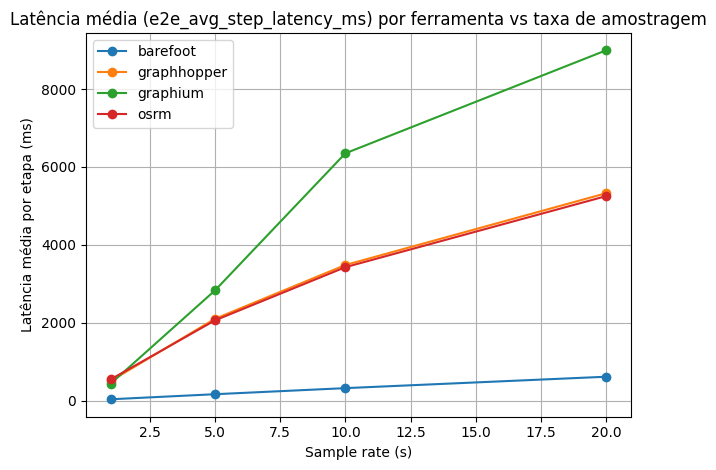

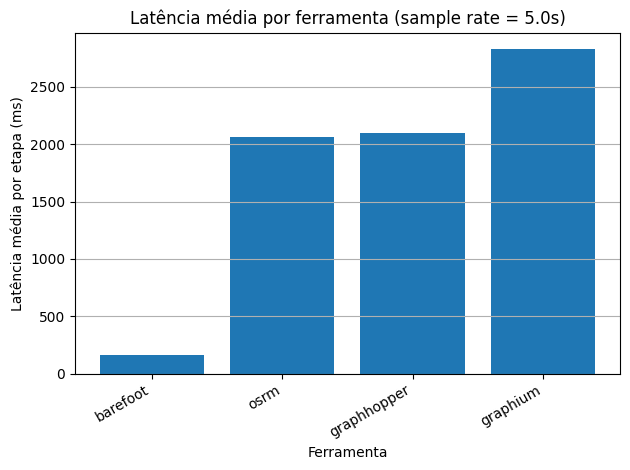

In [ ]:
# --------------------------------------------------
# Load data
# --------------------------------------------------
df = read_csv(final_path)

# --------------------------------------------------
# Extract sample rate from dataset_id_prom
# Example: ohare_filtered_vid_1139_sr_5.0 -> 5.0
# --------------------------------------------------
df = add_sample_rate(df, "dataset_id_prom")
df = df.dropna(subset=["sample_rate"])

# --------------------------------------------------
# QP2: Temporal efficiency (latency) vs sample rate
# Choose one latency metric to be consistent.
# Recommended: e2e_avg_step_latency_ms (average step latency in ms)
# --------------------------------------------------
lat_col = "e2e_avg_step_latency_ms"

# Keep only rows with latency available (some rows may be missing, e.g., failed runs)
df_lat = df.dropna(subset=[lat_col]).copy()

qp2_agg = (
    df_lat.groupby(["matcher_name", "sample_rate"], as_index=False)
    .agg(
        latency_mean_ms=(lat_col, "mean"),
        runs=(lat_col, "count"),
    )
    .sort_values(["matcher_name", "sample_rate"])
)

print(qp2_agg)

# --------------------------------------------------
# Plot: latency mean vs sample rate (line plot)
# --------------------------------------------------
plot_line_by_group(
    qp2_agg,
    x="sample_rate",
    y="latency_mean_ms",
    group="matcher_name",
    xlabel="Sample rate (s)",
    ylabel="Latência média por etapa (ms)",
    title="Latência média (e2e_avg_step_latency_ms) por ferramenta vs taxa de amostragem",
)


target_sr = 5.0
one = qp2_agg[qp2_agg["sample_rate"] == target_sr].sort_values("latency_mean_ms")
plt.figure()
plt.bar(one["matcher_name"], one["latency_mean_ms"])
plt.xlabel("Ferramenta")
plt.ylabel("Latência média por etapa (ms)")
plt.title(f"Latência média por ferramenta (sample rate = {target_sr}s)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


    matcher_variant  sample_rate  latency_mean_ms  steps
0          barefoot          1.0        34.617042  10538
1          barefoot          5.0       165.085977   2144
2          barefoot         10.0       323.018834   1096
3          barefoot         20.0       622.040391    564
4       graphhopper          1.0       315.497543   3584
5       graphhopper          5.0      1394.585863    774
6       graphhopper         10.0      2495.684464    432
7       graphhopper         20.0      4194.818088    254
8   graphium (cold)          1.0       268.713297   2097
9   graphium (cold)          5.0      1977.633275    276
10  graphium (cold)         10.0      5807.307656     94
11  graphium (cold)         20.0      8997.621100     60
12  graphium (warm)          1.0       243.296723   2038
13  graphium (warm)          5.0      1178.640857    216
14  graphium (warm)         10.0      1670.630167     34
15             osrm          1.0       364.599044   2478
16             osrm          5.

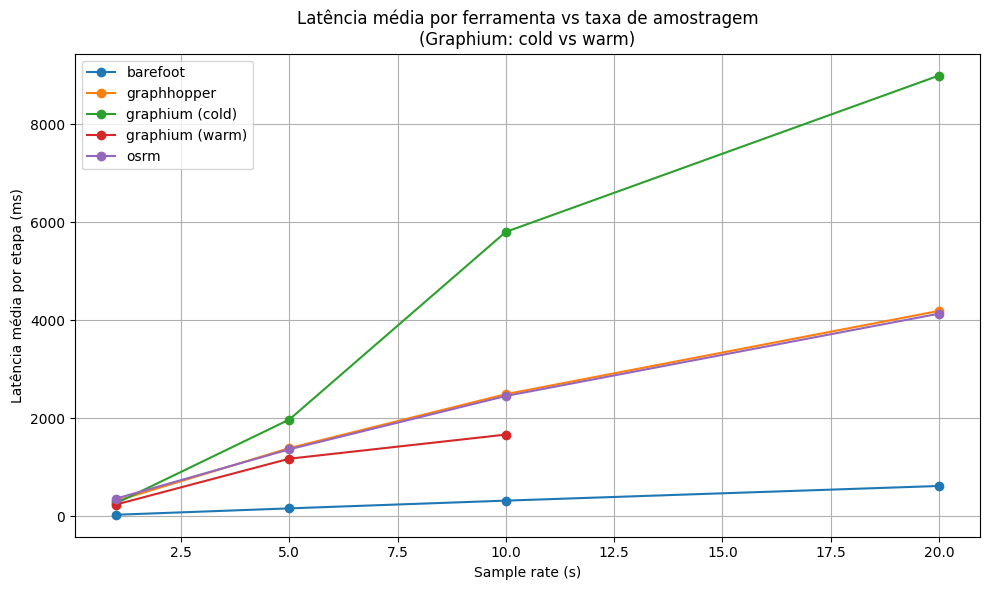

In [53]:
# --------------------------------------------------
# Load datasets
# --------------------------------------------------
final_df = read_csv(final_path)
e2e_df = read_csv(e2e_path)

# --------------------------------------------------
# Extract sample rate from dataset_id_mm
# Example: ohare_filtered_vid_1139_sr_5.0 -> 5.0
# --------------------------------------------------
final_df = add_sample_rate(final_df, "dataset_id_mm")

# --------------------------------------------------
# Join E2E steps with metadata
# --------------------------------------------------
df = e2e_df.merge(
    final_df[
        ["run_id", "matcher_name", "dataset_id_mm", "sample_rate", "batch_size_mm"]
    ],
    on="run_id",
    how="left",
    suffixes=("", "_meta"),
)
df = df.dropna(subset=["sample_rate"])

# --------------------------------------------------
# Create Graphium warm/cold views
# --------------------------------------------------
df["matcher_variant"] = df["matcher_name_meta"]
mask_graphium = df["matcher_name"] == "graphium"
df.loc[mask_graphium, "matcher_variant"] = "graphium (cold)"

df_warm = df[~((df["matcher_name"] == "graphium") & (df["step_index"] == 0))].copy()
df_warm.loc[df_warm["matcher_name"] == "graphium", "matcher_variant"] = (
    "graphium (warm)"
)

df_all = pd.concat([df, df_warm], ignore_index=True)

# --------------------------------------------------
# Aggregate latency (QP2)
# --------------------------------------------------
qp2_agg = (
    df_all.groupby(["matcher_variant", "sample_rate"], as_index=False)
    .agg(
        latency_mean_ms=("step_latency_ms", "mean"),
        steps=("step_latency_ms", "count"),
    )
    .sort_values(["matcher_variant", "sample_rate"])
)

print(qp2_agg)

# --------------------------------------------------
# Plot: Latency vs sample rate
# --------------------------------------------------
plot_line_by_group(
    qp2_agg,
    x="sample_rate",
    y="latency_mean_ms",
    group="matcher_variant",
    xlabel="Sample rate (s)",
    ylabel="Latência média por etapa (ms)",
    title="Latência média por ferramenta vs taxa de amostragem\n(Graphium: cold vs warm)",
    figsize=(10, 6),
)


    matcher_variant  sample_rate  latency_mean_ms  steps  runs
0          barefoot          1.0        34.617042   5269    20
1          barefoot          5.0       165.085977   1072    20
2          barefoot         10.0       323.018834    548    20
3          barefoot         20.0       622.040391    282    20
4       graphhopper          1.0       315.497543   1792    60
5       graphhopper          5.0      1394.585863    387    60
6       graphhopper         10.0      2495.684464    216    60
7       graphhopper         20.0      4194.818088    127    60
8   graphium (cold)          1.0       268.713297   2097    59
9   graphium (cold)          5.0      1977.633275    276    60
10  graphium (cold)         10.0      5807.307656     94    60
11  graphium (cold)         20.0      8997.621100     60    60
12  graphium (warm)          1.0       243.296723   2038    59
13  graphium (warm)          5.0      1329.032961    228    60
14  graphium (warm)         10.0      4384.956796     7

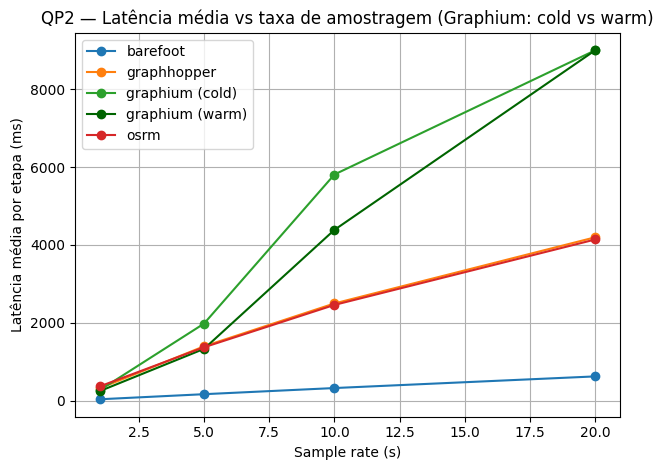

    matcher_variant  batch_size_mm  latency_mean_ms  steps  runs
0       graphhopper            5.0       492.587831   1481    80
1       graphhopper           10.0       954.260315    760    80
2       graphhopper           30.0      2569.842172    281    80
3   graphium (cold)            5.0       514.753779   1415    79
4   graphium (cold)           10.0      1011.400846    726    80
5   graphium (cold)           30.0      1897.433011    386    80
6   graphium (warm)            5.0       398.059331   1372    79
7   graphium (warm)           10.0       807.384684    682    80
8   graphium (warm)           30.0      1604.937782    342    80
9              osrm            5.0       665.148972    928    71
10             osrm           10.0       935.725211    760    80
11             osrm           30.0      2526.910941    281    80


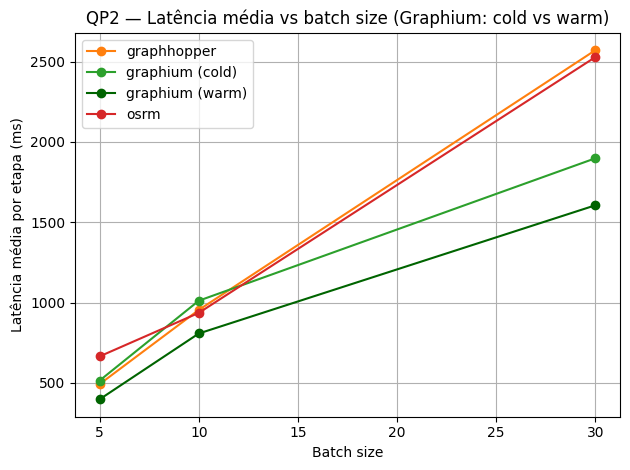

In [54]:
# --------------------------------------------------
# Load datasets
# --------------------------------------------------
final_df = read_csv(final_path)
e2e_df = read_csv(e2e_path)

# --------------------------------------------------
# Extract sample rate from dataset_id_mm (preferred) or dataset_id_prom fallback
# --------------------------------------------------
if "dataset_id_mm" in final_df.columns:
    final_df = add_sample_rate(final_df, "dataset_id_mm")
else:
    final_df = add_sample_rate(final_df, "dataset_id_prom")

# --------------------------------------------------
# Join E2E steps with run-level metadata
# --------------------------------------------------
meta_cols = ["run_id", "matcher_name_mm", "sample_rate"]
for c in ["batch_size_mm", "dataset_id_mm"]:
    if c in final_df.columns:
        meta_cols.append(c)

df = e2e_df.merge(final_df[meta_cols], on="run_id", how="left")

# Keep only rows we can analyze
df = df.dropna(subset=["matcher_name", "sample_rate", "step_latency_ms"]).copy()

# Ensure numeric
df["sample_rate"] = df["sample_rate"].astype(float)

# --------------------------------------------------
# Build matcher_variant with Graphium cold/warm
# Warm rule:
# - For runs with >1 step: drop step_index == 0
# - For runs with exactly 1 step: keep step_index == 0 (so warm exists)
# --------------------------------------------------
non_graph = df[df["matcher_name"] != "graphium"].copy()
non_graph["matcher_variant"] = non_graph["matcher_name"]

graph = df[df["matcher_name"] == "graphium"].copy()

# Cold = all steps
graph_cold = graph.copy()
graph_cold["matcher_variant"] = "graphium (cold)"

# Determine runs that have only 1 step
# (step_count == 1) OR (max step_index == 0) – both are safe checks
graph_run_steps = (
    graph.groupby("run_id", as_index=False)
    .agg(step_count=("step_index", "count"), max_step=("step_index", "max"))
)
graph = graph.merge(graph_run_steps, on="run_id", how="left")

# Warm selection:
# - if run has only 1 step (max_step == 0 or step_count == 1): keep it
# - else: exclude step 0
warm_mask = (graph["step_count"] == 1) | (graph["max_step"] == 0) | (graph["step_index"] != 0)
graph_warm = graph[warm_mask].copy()
graph_warm["matcher_variant"] = "graphium (warm)"

# Combine dataset for analysis
df_all = pd.concat([non_graph, graph_cold, graph_warm], ignore_index=True)

# --------------------------------------------------
# Fixed colors as requested
# --------------------------------------------------
COLOR = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium (cold)": "tab:green",
    "graphium (warm)": "darkgreen",
    "osrm": "tab:red",
}

# Optional: enforce consistent plotting order
PLOT_ORDER = ["barefoot", "graphhopper", "graphium (cold)", "graphium (warm)", "osrm"]

# --------------------------------------------------
# QP2 aggregation: latency vs sample_rate
# --------------------------------------------------
qp2_sr = (
    df_all.groupby(["matcher_variant", "sample_rate"], as_index=False)
    .agg(
        latency_mean_ms=("step_latency_ms", "mean"),
        steps=("step_latency_ms", "count"),
        runs=("run_id", pd.Series.nunique),
    )
    .sort_values(["matcher_variant", "sample_rate"])
)

print(qp2_sr)

# Plot: latency mean vs sample rate
plot_line_by_group(
    qp2_sr,
    x="sample_rate",
    y="latency_mean_ms",
    group="matcher_variant",
    xlabel="Sample rate (s)",
    ylabel="Latência média por etapa (ms)",
    title="QP2 — Latência média vs taxa de amostragem (Graphium: cold vs warm)",
    order=PLOT_ORDER,
    colors=COLOR,
)

# --------------------------------------------------
# QP2 aggregation: latency vs batch_size (if available)
# --------------------------------------------------
batch_col = "batch_size_mm" if "batch_size_mm" in df_all.columns else None

if batch_col:
    df_b = df_all.dropna(subset=[batch_col]).copy()
    df_b[batch_col] = pd.to_numeric(df_b[batch_col], errors="coerce")
    df_b = df_b.dropna(subset=[batch_col])

    qp2_bs = (
        df_b.groupby(["matcher_variant", batch_col], as_index=False)
        .agg(
            latency_mean_ms=("step_latency_ms", "mean"),
            steps=("step_latency_ms", "count"),
            runs=("run_id", pd.Series.nunique),
        )
        .sort_values(["matcher_variant", batch_col])
    )

    print(qp2_bs)

    plot_line_by_group(
        qp2_bs,
        x=batch_col,
        y="latency_mean_ms",
        group="matcher_variant",
        xlabel="Batch size",
        ylabel="Latência média por etapa (ms)",
        title="QP2 — Latência média vs batch size (Graphium: cold vs warm)",
        order=PLOT_ORDER,
        colors=COLOR,
    )
else:
    print("batch_size_mm não encontrado no metadata; pulei o gráfico por batch size.")


In [55]:
# 1) Garantir tipo numérico do step_index
df_all_check = df.copy()
df_all_check["step_index"] = pd.to_numeric(df_all_check["step_index"], errors="coerce")

# 2) Para graphium, ver quantos runs realmente têm 1 step por sample_rate
g = df_all_check[df_all_check["matcher_name"] == "graphium"].copy()

per_run = (
    g.groupby(["run_id", "sample_rate"], as_index=False)
     .agg(n_steps=("step_index", "nunique"), max_step=("step_index", "max"))
)

print(
    per_run.groupby("sample_rate")
           .agg(runs=("run_id","nunique"),
                runs_1step=("n_steps", lambda s: (s==1).sum()),
                runs_gt1=("n_steps", lambda s: (s>1).sum()))
           .reset_index()
)

# 3) Olhar exemplos de runs_1step em sr=10 (se existir)
print(per_run[(per_run["sample_rate"]==10.0) & (per_run["n_steps"]==1)].head(10))


   sample_rate  runs  runs_1step  runs_gt1
0          1.0    59           0        59
1          5.0    60          12        48
2         10.0    60          36        24
3         20.0    60          60         0
                              run_id  sample_rate  n_steps  max_step
0   0020fcef10544182a0e5f7c4cb43c341         10.0        1         0
15  0fd4f30c071f470bb241195a63f7d04e         10.0        1         0
17  16bd37a2dfdb457eac87353817ef1606         10.0        1         0
27  2260bdb624fd4ab699bfd9570364b76c         10.0        1         0
28  22dede54f2714b2d82d5fdeb6dbeaf09         10.0        1         0
32  26c4cd27b97c49538a3c6b8229bfb65d         10.0        1         0
38  2d1adfd4f5684f95957aee154657f78f         10.0        1         0
39  2ff0d3bc94994bb3b9fd5cc2c833f430         10.0        1         0
40  306db9f854884482b4c301ad4f280ad2         10.0        1         0
45  331d6102ced6422bada0b0f796427434         10.0        1         0
